In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

tickers = ["AMD", "AAPL", "MSFT", "GOOGL", "META", "NVDA", "ABNB", "TSLA", "AMZN", "NFLX"]
os.makedirs("data/eda", exist_ok=True)

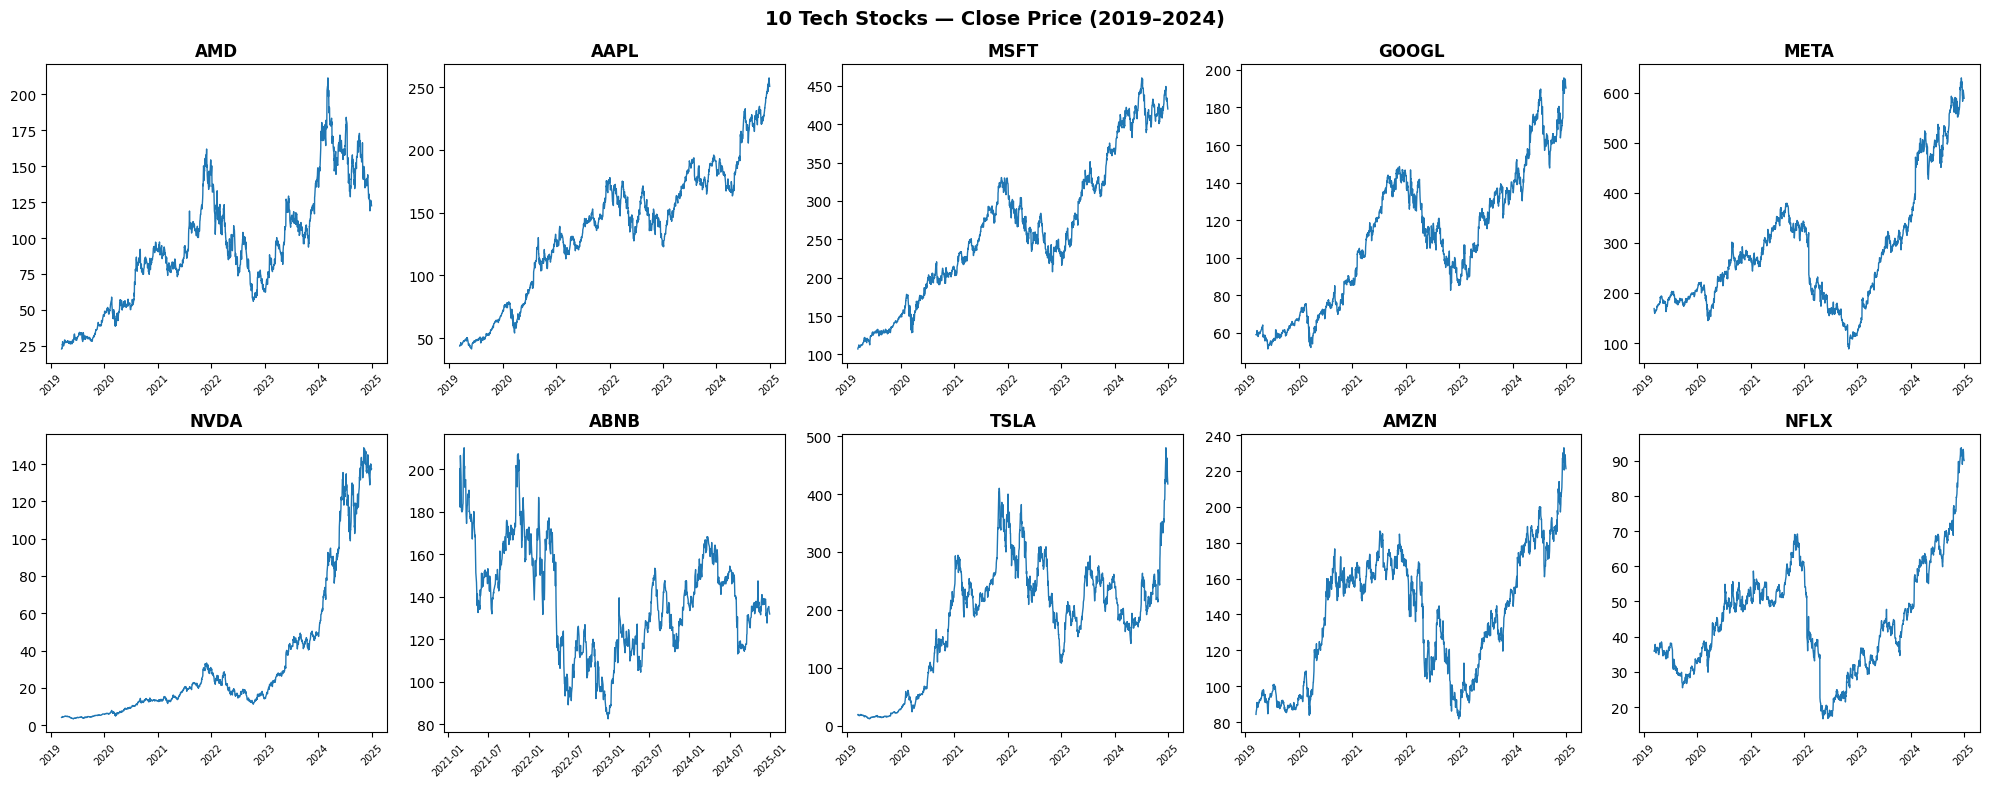

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0, parse_dates=True)
    axes[i].plot(df.index, df["Close"], linewidth=1)
    axes[i].set_title(ticker, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle("10 Tech Stocks — Close Price (2019–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/eda/all_stocks_price.png", dpi=150)
plt.show()

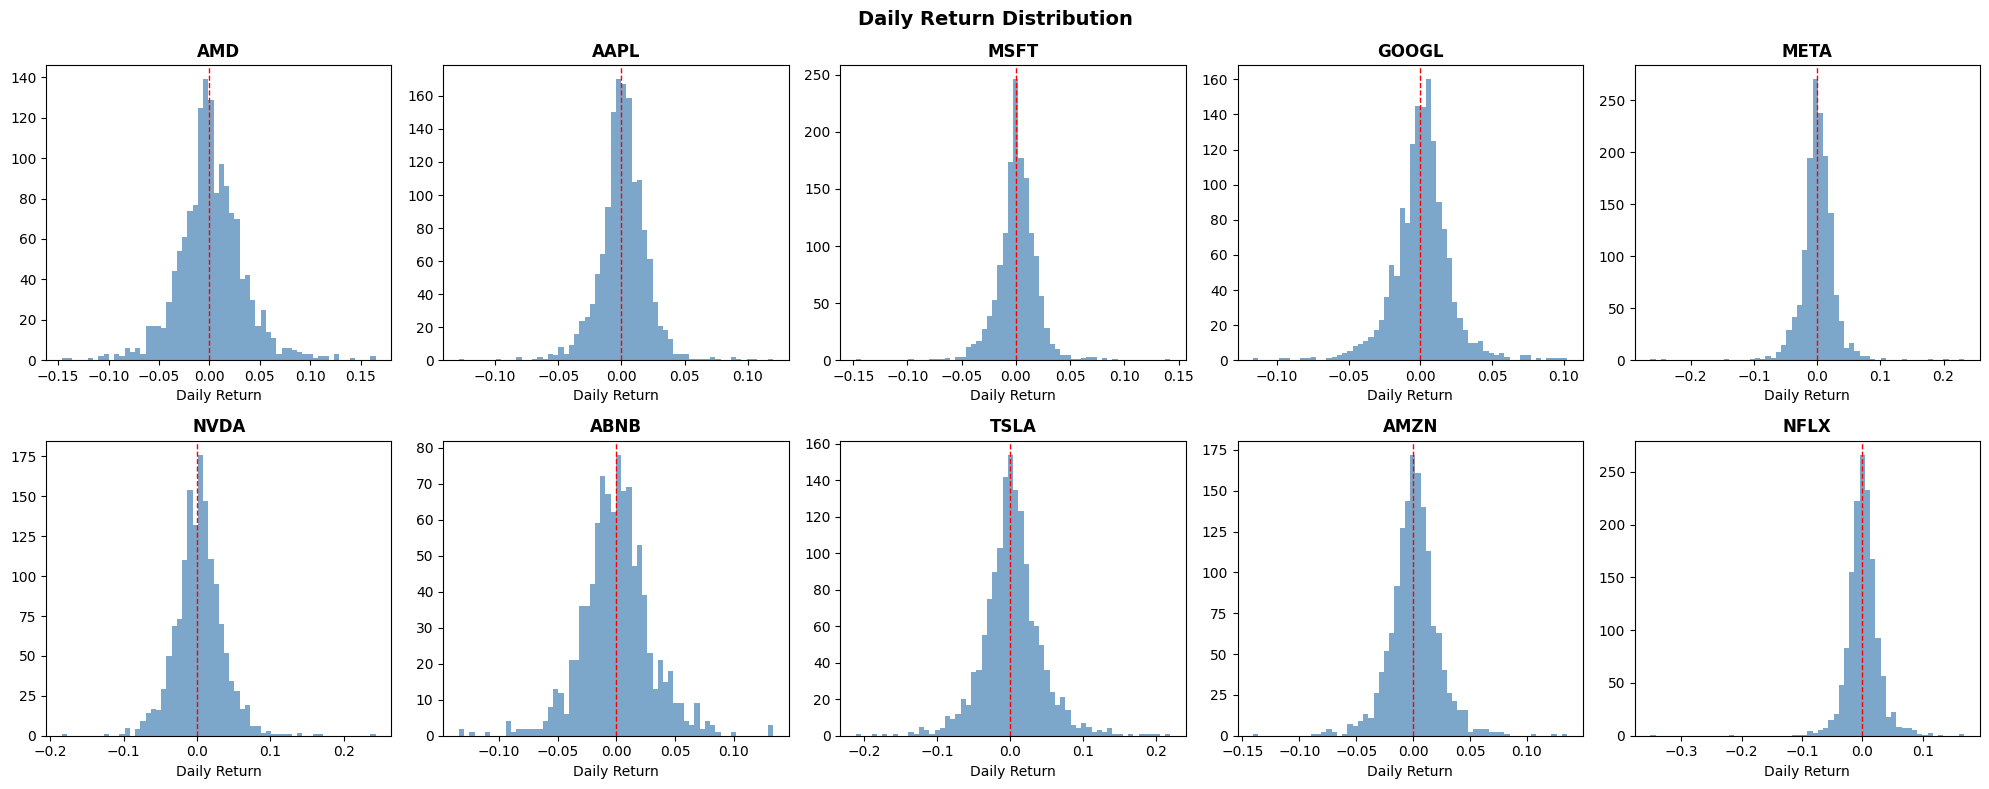

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0, parse_dates=True)
    axes[i].hist(df["Return_1d"], bins=60, edgecolor="none", alpha=0.7, color="steelblue")
    axes[i].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(ticker, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Daily Return")

plt.suptitle("Daily Return Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/eda/return_distribution.png", dpi=150)
plt.show()

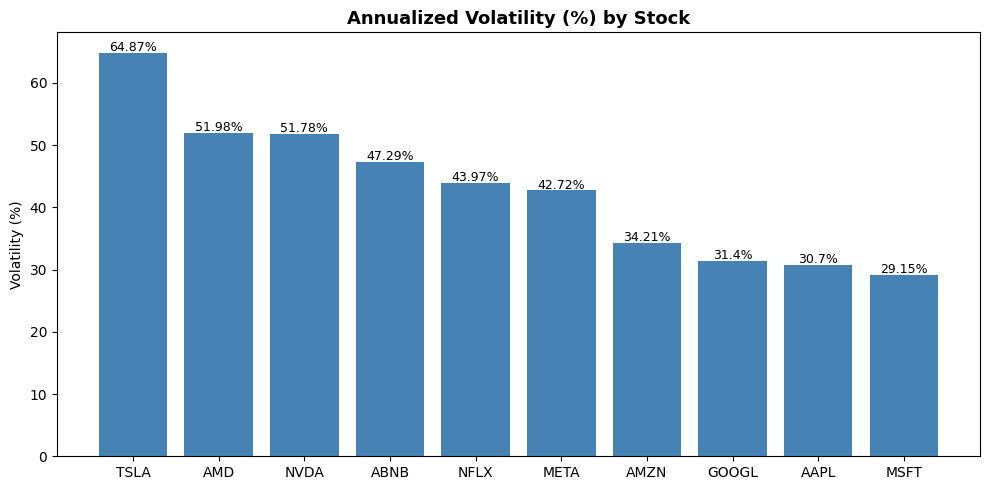

TSLA     64.87
AMD      51.98
NVDA     51.78
ABNB     47.29
NFLX     43.97
META     42.72
AMZN     34.21
GOOGL    31.40
AAPL     30.70
MSFT     29.15
dtype: float64


In [4]:
volatility = {}
for ticker in tickers:
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0)
    annual_vol = df["Return_1d"].std() * (252 ** 0.5)
    volatility[ticker] = round(annual_vol * 100, 2)

vol_df = pd.Series(volatility).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(vol_df.index, vol_df.values, color="steelblue", edgecolor="none")
plt.title("Annualized Volatility (%) by Stock", fontsize=13, fontweight="bold")
plt.ylabel("Volatility (%)")
for bar, val in zip(bars, vol_df.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val}%", 
             ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/eda/volatility_comparison.png", dpi=150)
plt.show()
print(vol_df)

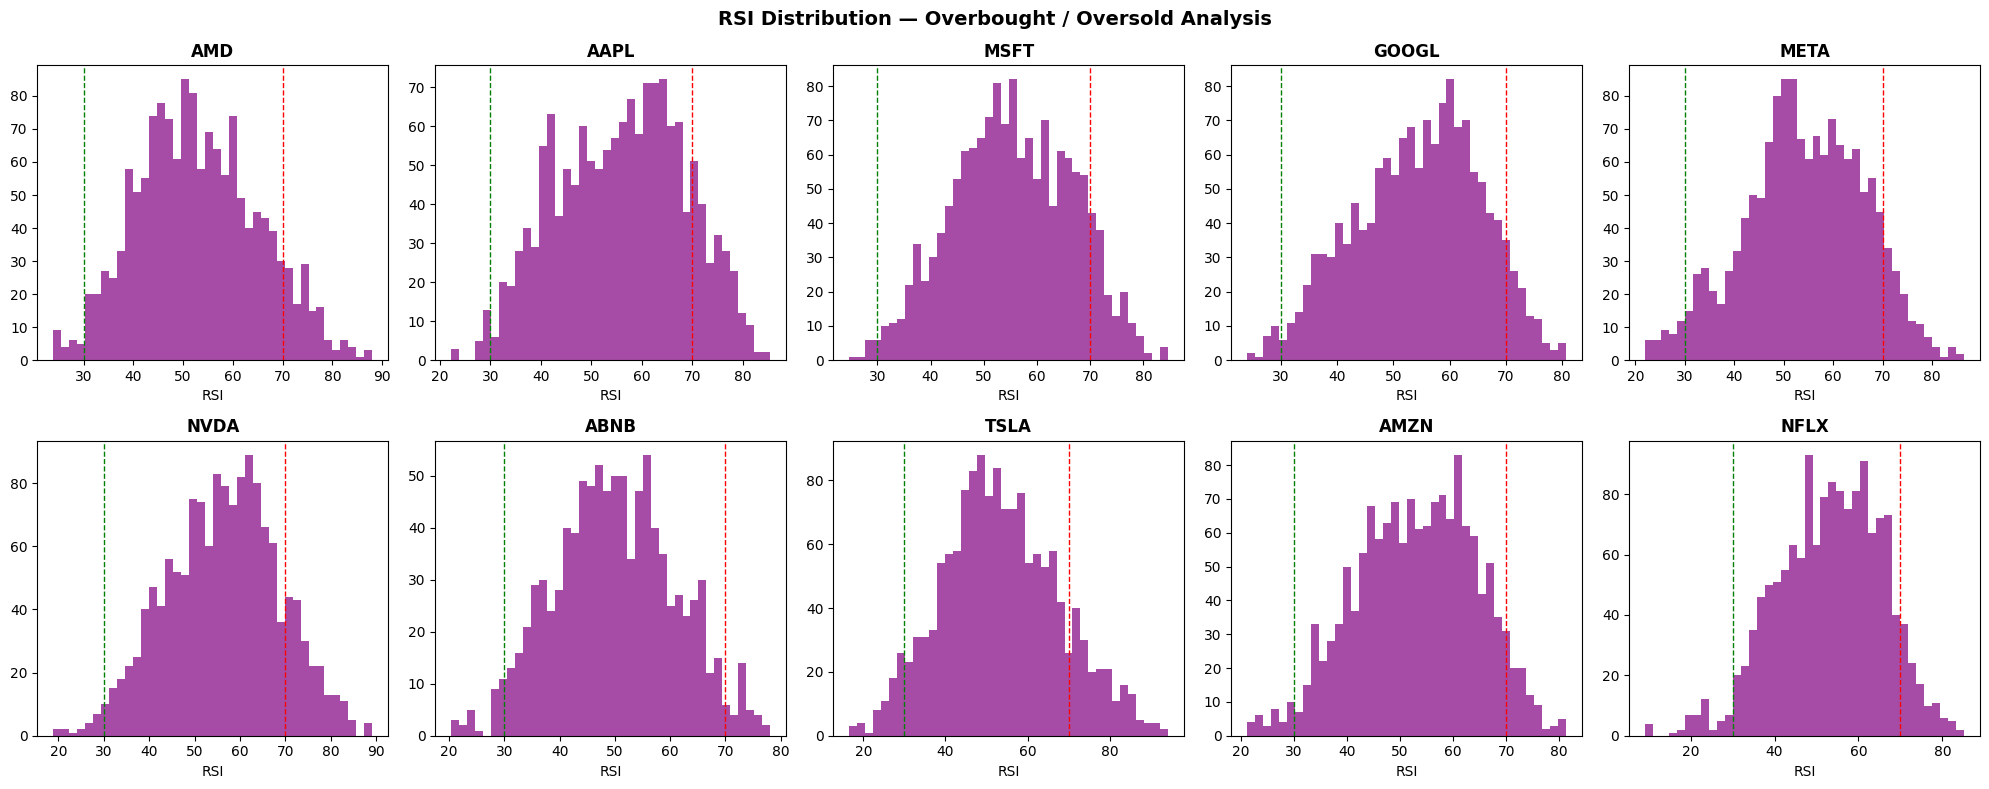

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0)
    axes[i].hist(df["RSI_14"], bins=40, color="purple", alpha=0.7, edgecolor="none")
    axes[i].axvline(70, color="red", linestyle="--", linewidth=1, label="Overbought")
    axes[i].axvline(30, color="green", linestyle="--", linewidth=1, label="Oversold")
    axes[i].set_title(ticker, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("RSI")

plt.suptitle("RSI Distribution — Overbought / Oversold Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/eda/rsi_distribution.png", dpi=150)
plt.show()

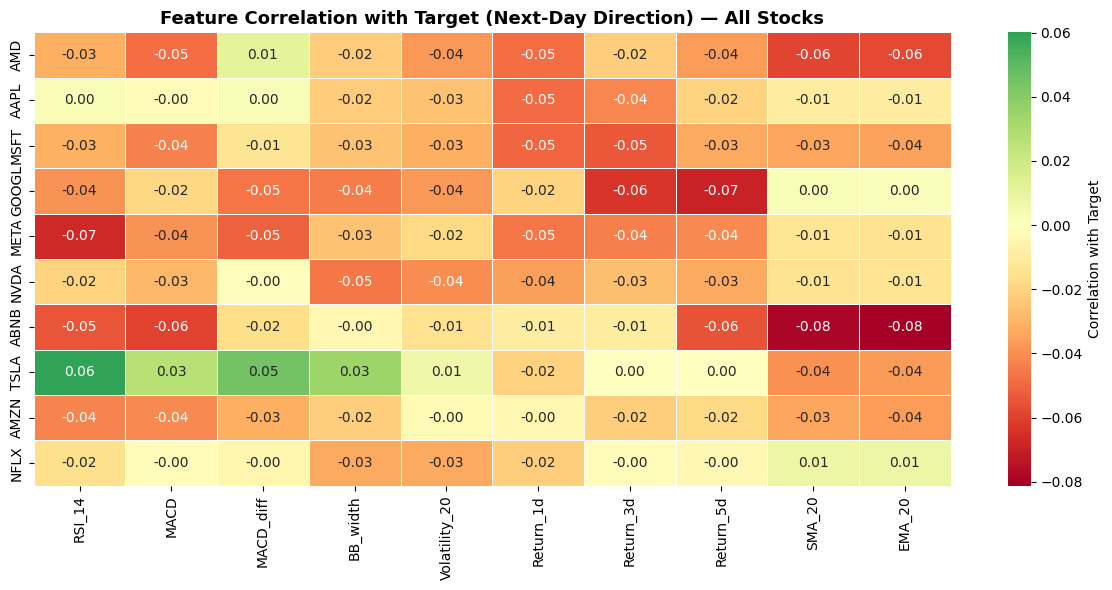

In [6]:
feature_cols = ["RSI_14", "MACD", "MACD_diff", "BB_width",
                "Volatility_20", "Return_1d", "Return_3d", "Return_5d",
                "SMA_20", "EMA_20"]

corr_summary = {}
for ticker in tickers:
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0)
    corr = df[feature_cols].corrwith(df["Target"])
    corr_summary[ticker] = corr

corr_df = pd.DataFrame(corr_summary).T

plt.figure(figsize=(12, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation with Target"})
plt.title("Feature Correlation with Target (Next-Day Direction) — All Stocks", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/eda/feature_target_correlation.png", dpi=150)
plt.show()

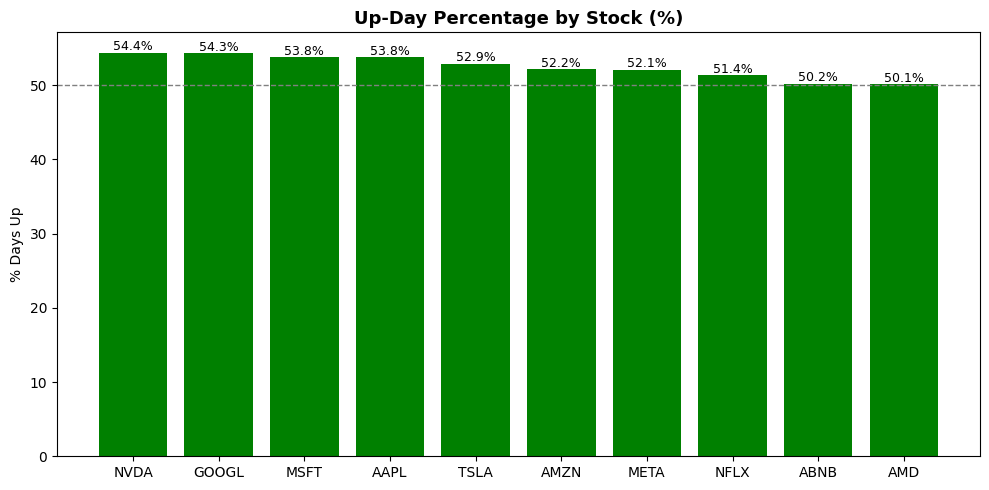

NVDA     54.4
GOOGL    54.3
MSFT     53.8
AAPL     53.8
TSLA     52.9
AMZN     52.2
META     52.1
NFLX     51.4
ABNB     50.2
AMD      50.1
dtype: float64


In [7]:
target_dist = {}
for ticker in tickers:
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0)
    up_pct = df["Target"].mean() * 100
    target_dist[ticker] = round(up_pct, 1)

td = pd.Series(target_dist).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(td.index, td.values, color=["green" if v >= 50 else "red" for v in td.values], edgecolor="none")
plt.axhline(50, color="gray", linestyle="--", linewidth=1)
plt.title("Up-Day Percentage by Stock (%)", fontsize=13, fontweight="bold")
plt.ylabel("% Days Up")
for bar, val in zip(bars, td.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val}%",
             ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/eda/target_distribution.png", dpi=150)
plt.show()
print(td)

In [8]:
print("=== Week 4 EDA Summary ===")
print()
for ticker in tickers:
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0)
    print(f"{ticker}:")
    print(f"  样本数: {len(df)}")
    print(f"  上涨天占比: {df['Target'].mean()*100:.1f}%")
    print(f"  年化波动率: {df['Return_1d'].std()*(252**0.5)*100:.1f}%")
    print(f"  RSI均值: {df['RSI_14'].mean():.1f}")
    print()

=== Week 4 EDA Summary ===

AMD:
  样本数: 1460
  上涨天占比: 50.1%
  年化波动率: 52.0%
  RSI均值: 53.0

AAPL:
  样本数: 1460
  上涨天占比: 53.8%
  年化波动率: 30.7%
  RSI均值: 55.9

MSFT:
  样本数: 1460
  上涨天占比: 53.8%
  年化波动率: 29.2%
  RSI均值: 55.5

GOOGL:
  样本数: 1460
  上涨天占比: 54.3%
  年化波动率: 31.4%
  RSI均值: 54.4

META:
  样本数: 1460
  上涨天占比: 52.1%
  年化波动率: 42.7%
  RSI均值: 54.2

NVDA:
  样本数: 1460
  上涨天占比: 54.4%
  年化波动率: 51.8%
  RSI均值: 56.3

ABNB:
  样本数: 970
  上涨天占比: 50.2%
  年化波动率: 47.3%
  RSI均值: 50.0

TSLA:
  样本数: 1460
  上涨天占比: 52.9%
  年化波动率: 64.9%
  RSI均值: 53.6

AMZN:
  样本数: 1460
  上涨天占比: 52.2%
  年化波动率: 34.2%
  RSI均值: 53.1

NFLX:
  样本数: 1460
  上涨天占比: 51.4%
  年化波动率: 44.0%
  RSI均值: 53.1

